In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib

In [86]:
df = pd.read_csv('청년정책목록_전체.csv', encoding='utf-8')

# 만료된 데이터 제거

In [87]:
df[['bizPrdSeCd', 'bizPrdBgngYmd', 'bizPrdEndYmd', 'bizPrdEtcCn', 'aplyYmd']].head(20)

,bizPrdSeCd,bizPrdBgngYmd,bizPrdEndYmd,bizPrdEtcCn,aplyYmd
0,56002.0,,,연중,20250523 ~ 20250623
1,56001.0,20250101,20251231,NaN,NaN
2,56001.0,20250101,20251231,NaN,20250201 ~ 20250930\N20250414 ~ 20250417
3,56001.0,20250101,20251231,NaN,20250609 ~ 20250620
4,56001.0,20250101,20251231,NaN,20250301 ~ 20251130
5,56001.0,20250528,20251231,NaN,20250528 ~ 20250528
6,56001.0,20250401,20251231,NaN,NaN
7,56001.0,20250101,20251231,NaN,NaN
8,56001.0,20250526,20251231,NaN,20250526 ~ 20250531
9,56002.0,,,연중,20250422 ~ 20251231


In [88]:
# 사업기간종료일자가 결측치인 데이터 개수
len(df[df['bizPrdEndYmd'].isnull()])

2701

In [89]:
# 사업기간종료일자가 결측치인 데이터 중 사업기간기타내용이 있는 데이터 개수
len(df[df['bizPrdEndYmd'].isnull() & df['bizPrdEtcCn'].notnull()])

1428

In [91]:
# 사업기간기타내용 값의 빈도수 
df[df['bizPrdEtcCn'].notnull()]['bizPrdEtcCn'].value_counts()

bizPrdEtcCn
-                                        818
상시                                        54
2024.01.01.~2024.12.31.                   33
연중                                        31
2024. 1. ~ 12.                            22
                                        ... 
활동기간: 1년(2024. 2. 18. ~ 2025. 2. 17.)      1
20180101~99991231                          1
입사기간: 2024년 3월~2025년 2월\n※ 방학기간 포함         1
독립경영(영농) 기간에 따라 차등 지원                      1
2024.03. ~ 2024.11.                        1
Name: count, Length: 612, dtype: int64

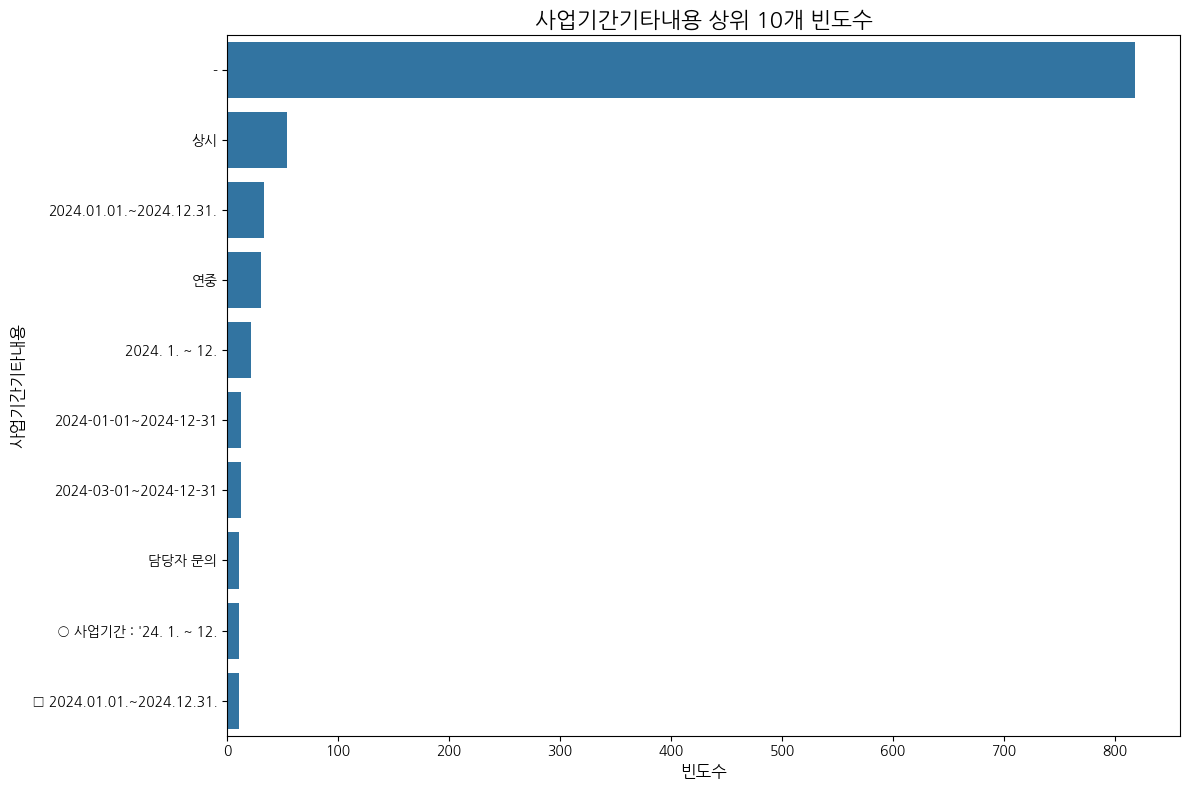

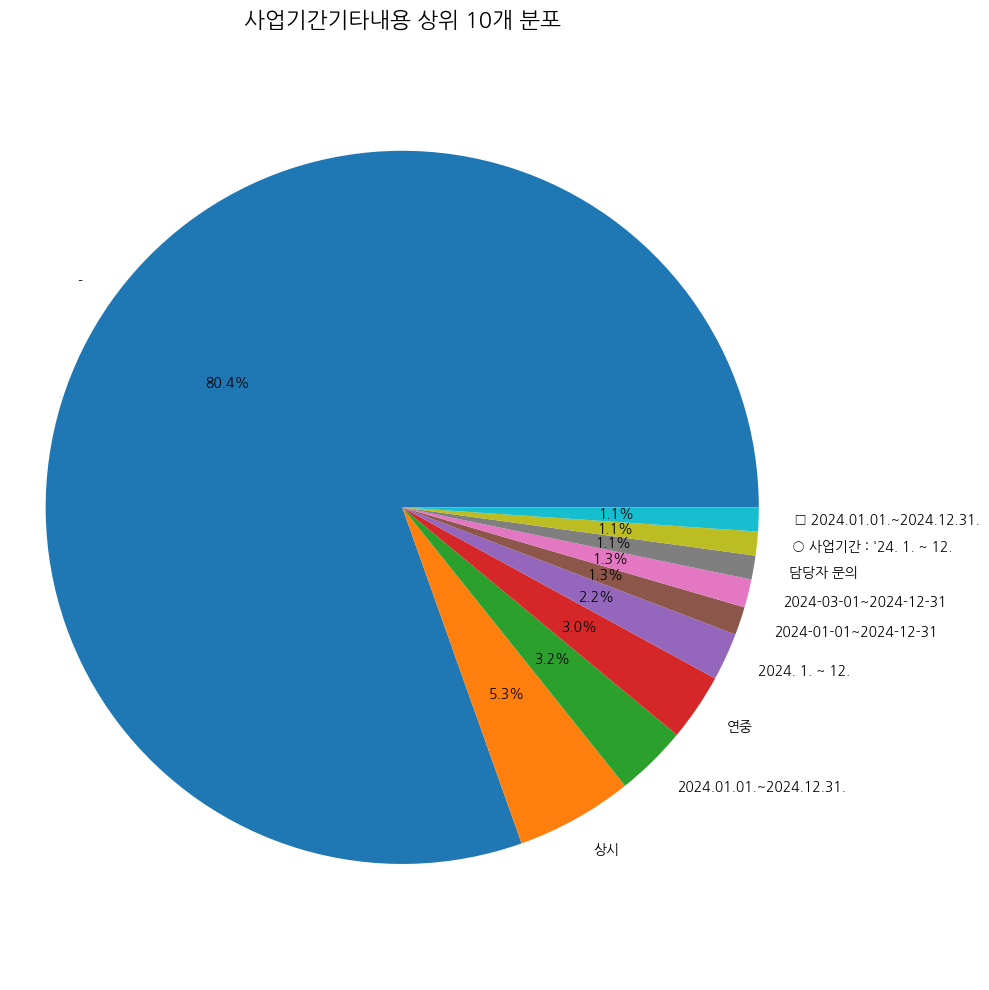

In [92]:
# 사업기간기타내용 값의 빈도수를 구하고 상위 10개 추출
etc_content_counts = df[df['bizPrdEtcCn'].notnull()]['bizPrdEtcCn'].value_counts().head(10)

# 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x=etc_content_counts.values, y=etc_content_counts.index)
plt.title('사업기간기타내용 상위 10개 빈도수', fontsize=16)
plt.xlabel('빈도수', fontsize=12)
plt.ylabel('사업기간기타내용', fontsize=12)
plt.tight_layout()
plt.show()

# 더 나은 가독성을 위해 파이 차트로도 시각화
plt.figure(figsize=(10, 10))
plt.pie(etc_content_counts.values, labels=etc_content_counts.index, autopct='%1.1f%%')
plt.title('사업기간기타내용 상위 10개 분포', fontsize=16)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [102]:
df[df['bizPrdEtcCn'] == '2024.01.01.~2024.12.31.'][['plcyNm', 'plcyKywdNm', 'plcyExplnCn', 'bizPrdSeCd', 'bizPrdBgngYmd', 'bizPrdEndYmd', 'bizPrdEtcCn', 'aplyYmd']]

,plcyNm,plcyKywdNm,plcyExplnCn,bizPrdSeCd,bizPrdBgngYmd,bizPrdEndYmd,bizPrdEtcCn,aplyYmd
933,공공기관 직원 통합채용(광주),NaN,산하 공공기관 정기채용 市주관 통합채용을 실시하여 채용 투명성 및 신뢰성 증진,NaN,NaN,NaN,2024.01.01.~2024.12.31.,20240101 ~ 20241231
1242,대학일자리플러스센터 운영지원,장기미취업청년,"광주 지역 대학 재학/졸업생 및 지역 청년들의 진로지도 및 전문상담, 취업지원 프로...",NaN,NaN,NaN,2024.01.01.~2024.12.31.,NaN
1384,문화콘텐츠 전문인력 양성 및 취업지원,장기미취업청년,"대학 및 기업연계 현장맞춤형 문화콘텐츠(첨단실감, AI융합 포함) 실무교육으로 전문...",NaN,NaN,NaN,2024.01.01.~2024.12.31.,NaN
1535,청년 창업점포 운영,NaN,청년 창업 도전 장려 및 지역경제 활성화,NaN,NaN,NaN,2024.01.01.~2024.12.31.,NaN
1538,청년일자리창출사업,장기미취업청년,"지역기반 사회적기업, 협동조합, 비영리단체 등 일자리 발굴 및 청년에 일경험 제공",NaN,NaN,NaN,2024.01.01.~2024.12.31.,NaN
1539,맞춤형 공공원룸주택 (창업인의 집),공공임대주택,(예비)창업자 주거 및 사무공간 지원,NaN,NaN,NaN,2024.01.01.~2024.12.31.,NaN
1541,서울 청년센터 은평 운영,NaN,"종합상담지원, 정보제공, 네트워크 관계망 지원, 청년 맞춤형 자율사업 시행 등 청년...",NaN,NaN,NaN,2024.01.01.~2024.12.31.,NaN
1681,구직청년 면접용 정장 대여,장기미취업청년,면접용 정장 무료 대여,NaN,NaN,NaN,2024.01.01.~2024.12.31.,20240704 ~ 20241220
1691,광주일자리종합지원센터 취업지원,장기미취업청년,"취업정보 제공 및 취업지원 사업을 통해 지역 청년들의 취업 역량을 강화하고, 취업률...",NaN,NaN,NaN,2024.01.01.~2024.12.31.,NaN
1783,서리풀 청년아트갤러리,NaN,"관내 예술의전당 앞 지하보도의 복합문화공간을 활용하여 청년예술인에 무료 대관, 작품...",NaN,NaN,NaN,2024.01.01.~2024.12.31.,NaN


In [101]:
df[df['bizPrdEtcCn'] == '상시'][['plcyNm', 'plcyKywdNm', 'plcyExplnCn', 'bizPrdSeCd', 'bizPrdBgngYmd', 'bizPrdEndYmd', 'bizPrdEtcCn', 'aplyYmd']]

,plcyNm,plcyKywdNm,plcyExplnCn,bizPrdSeCd,bizPrdBgngYmd,bizPrdEndYmd,bizPrdEtcCn,aplyYmd
15,서울시 청년해외봉사단,해외진출,청년들의 국제개발협력사업 참여기회 확대 및 봉사활동을 통한 글로벌 역량 강화 지원,56002.0,,,상시,20250501 ~ 20250520
19,대전청년하우스,공공임대주택,청년근로자의 주거안정 및 주거복지 향상을 통한 지역정착 유도,56002.0,,,상시,NaN
21,청년내일저축계좌,금리혜택,일하는 저소득층 청년들이 안정적으로 자산을 형성해 나갈 수 있도록 지원하는 청년자산...,56002.0,,,상시,20250502 ~ 20250521
22,청년 주택드림 디딤돌 대출,대출,청년의 주거사다리 지원을 위해 청년 주택드림 통장으로 청약 당첨 시 주택구입자금을 대출,56002.0,,,상시,NaN
66,모자건강증진 사업,"맞춤형상담서비스,출산",임산부와 태아의 건강증진 도모,56002.0,,,상시,NaN
67,임신축하금 지원,보조금,임신부의 건강관리 지원 및 경제적부담 경감,56002.0,,,상시,NaN
68,의왕시 산모건강관리사 본인부담금 지원,"바우처,보조금,출산",산모회복과 신생아 양육 지원으로 모자건강증진 및 출산가정 경제적 부담 경감,56002.0,,,상시,NaN
70,출산장려금 지원,출산,출산 가정에 출산장려금 지원으로 경제적 부담 경감 및 출산 장려 분위기 조성,56002.0,,,상시,NaN
72,의왕시 산후조리비 지원,출산,출산가정에 산후조리비 지원으로 산후 건강보호 및 건전한 출산·양육 환경 조성,56002.0,,,상시,NaN
101,사회복무요원 장병내일준비적금 가입 시 사회복귀준비금 지원,보조금,연도별 매칭비율에 해당하는 금액을 사회복무요원 복무만료 시 국가가 추가로 지원하는 ...,56002.0,,,상시,NaN


In [103]:
df_filtered = df[df['bizPrdEtcCn'] != '2024.01.01. ~ 2024.12.31.']

In [104]:
len(df_filtered)

3458